<a href="https://colab.research.google.com/github/adrianmrizo/Client-Segmentation-Analysis/blob/main/Adrian_Travel_Tide_Mastery_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Travel Tide - Client Segmentation**

## 1. EDA before cohort cut-off

I had the suspicion that the cohort definition of session > 7 could be too rigurous, thats why I counducted several analysis on SQL to see whether we were missing importnat datapoints.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

#I've created these tables in SQL to make viual analysis of my findings

#import "sessions vs users" dataset
data_spu = '/content/sessions_per_user.csv' # Firste EDA showing the distributions of user per session bucket
data_cumulative = '/content/cumulative_revenue_per_sessions.csv' # Revenue per Session Bucket
data_bucket = '/content/summary_cut_off_criteria.csv' #Session Bucket vs differente metric to decide the cohort cut-off
data_convers = '/content/booking_rate.csv'#Booking rate pper Session bucket


#Create DataFrame of the first dataset
df_spu = pd.read_csv(data_spu)
df_spu.head()

,user_id,total_sessions
0,507513,12
1,522086,11
2,512706,11
3,566059,11
4,520063,11


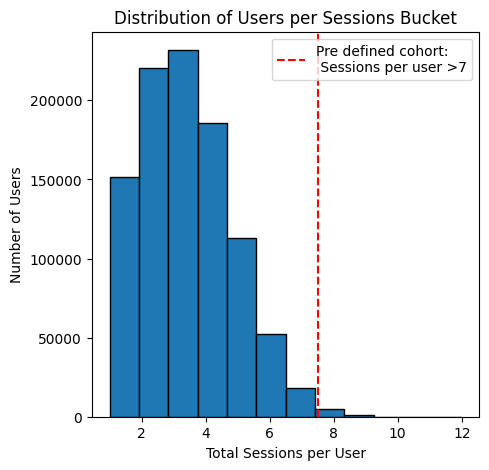

In [ ]:
# first I wanted to know how many users we have in our predefinde cohort (sessions>7 and last sessons from 2023-05-01)
# compared to our total users applying only the date filter (sessions from 2023-05-01)
plt.figure(figsize=(5,5))
plt.hist(df_spu['total_sessions'], bins=12, edgecolor='black',)
plt.xlabel("Total Sessions per User")
plt.ylabel("Number of Users")
plt.title("Distribution of Users per Sessions Bucket")
plt.axvline(7.5, color='red', linestyle='--', label='Pre defined cohort: \n Sessions per user >7')
plt.legend()
plt.show()

After running the following query I found out that with our cohort definition we ar excluding more than the 99% of the users. The query result said that we are working with only 0,59% of the users, less than 1%. I'll conduct further analysis two verify if the pre defined cohort has a meaninful definiton.

In [ ]:
df_cumulative = pd.read_csv(data_cumulative)
df_bucket = pd.read_csv(data_bucket)
df_convers = pd.read_csv(data_convers)

df_cumulative.head()

,total_sessions,bucket_revenue,cumulative_revenue,cumulative_revenue_pct
0,12,0,0,0.0000
1,11,31603,31603,0.0014
2,10,468317,499920,0.0216
3,9,3475773,3975693,0.1718
4,8,16924742,20900435,0.9031


In [ ]:
df_bucket.head()


,total_sessions,users,total_trips,total_completed_trips,avg_trips_per_user,avg_complete_trips,avg_cancelled_trips,cancel_rate,avg_revenue_per_user
0,1,151419,88450,83831,0.5841,0.5536,0.0305,5.2222,1571.26
1,2,220315,205307,191043,0.9319,0.8671,0.0647,6.9476,2120.18
2,3,231808,296633,282766,1.2796,1.2198,0.0598,4.6748,2353.14
3,4,185735,301292,291156,1.6222,1.5676,0.0546,3.3642,2628.70
4,5,113045,220609,214324,1.9515,1.8959,0.0556,2.8489,2896.12


In [ ]:
df_convers.head()

,total_sessions,total_sessions_count,total_bookings,booking_rate
0,1,151419,88450,58.41
1,2,440630,217510,49.36
2,3,695424,309028,44.44
3,4,742940,310686,41.82
4,5,565225,226587,40.09


In [ ]:
df_cumulative.info()
df_bucket.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   total_sessions          12 non-null     int64  
 1   bucket_revenue          12 non-null     int64  
 2   cumulative_revenue      12 non-null     int64  
 3   cumulative_revenue_pct  12 non-null     float64
dtypes: float64(1), int64(3)
memory usage: 516.0 bytes
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   total_sessions         12 non-null     int64  
 1   users                  12 non-null     int64  
 2   total_trips            12 non-null     int64  
 3   total_completed_trips  12 non-null     int64  
 4   avg_trips_per_user     12 non-null     float64
 5   avg_complete_trips     12 non-null     float64
 6   av

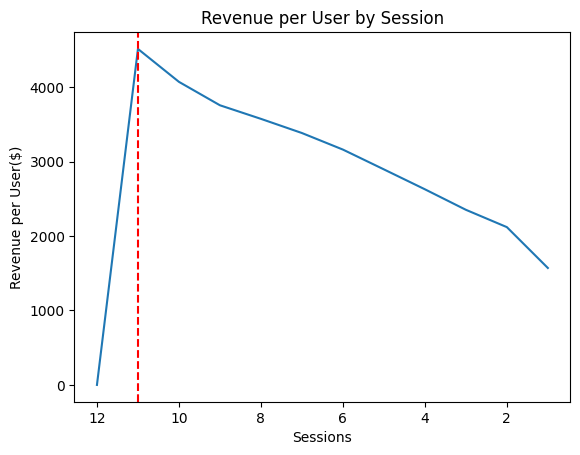

In [ ]:
# Revenue per user per session bucket
# I want to see whether there wa s a difference between users from higher sessions vs lower sessions users at revenue level
plt.figure()

plt.plot(
    df_bucket['total_sessions'],
    df_bucket['avg_revenue_per_user']
)

plt.xlabel("Sessions")
plt.ylabel("Revenue per User($)")
plt.axvline(11, color='red', linestyle='--')
plt.title("Revenue per User by Session")

plt.gca().invert_xaxis()

plt.show()

Users with more sessions have more average revenue per user, being "Sessions = 11" the highest. The exception was "Sessions = 12" where only one user doesn't have any bookings yet.

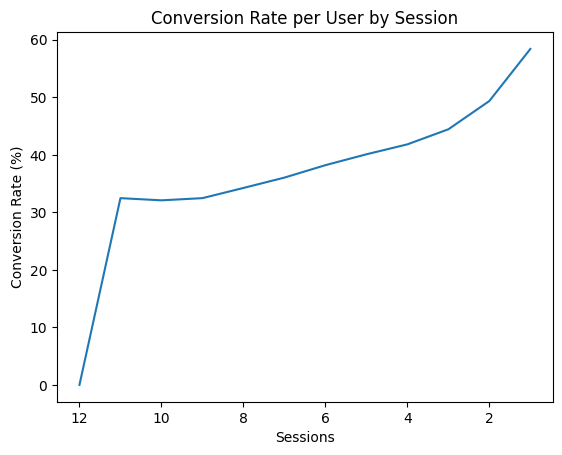

In [ ]:
# Convertion Rate
# I wanted to see whether higher session numbers implies higher convertion rate
plt.figure()

plt.plot(
    df_convers['total_sessions'],
    df_convers['booking_rate']
)

plt.xlabel("Sessions")
plt.ylabel("Conversion Rate (%)")
plt.title("Conversion Rate per User by Session")

plt.gca().invert_xaxis()

plt.show()

BUt we also see that the convertion rate drops with the number of sessions

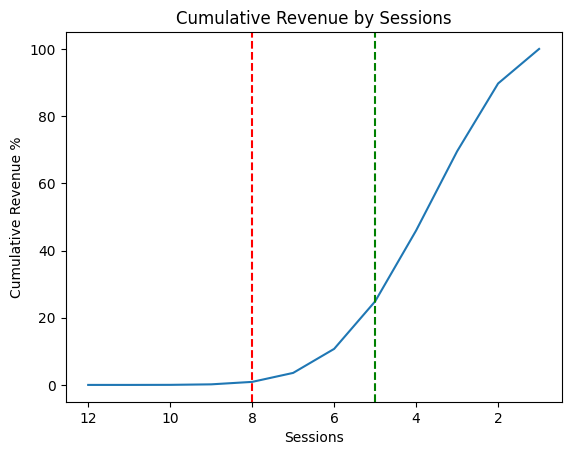

In [ ]:
# How much our cohort aports to the overall revenue of the company?

plt.figure()

plt.plot(
    df_cumulative['total_sessions'],
    df_cumulative['cumulative_revenue_pct']
)

plt.xlabel("Sessions")
plt.ylabel("Cumulative Revenue %")
plt.axvline(8, color='red', linestyle='--')
plt.axvline(5, color='green', linestyle='--')
plt.title("Cumulative Revenue by Sessions")

plt.gca().invert_xaxis()

plt.show()

The revenue share per session bucket, tell us that our pre defined coohort session > 7 has les than 1% of the total revenue share. Sessions >= 4 has almost the half of the share (46%). That could be a good staritng point.

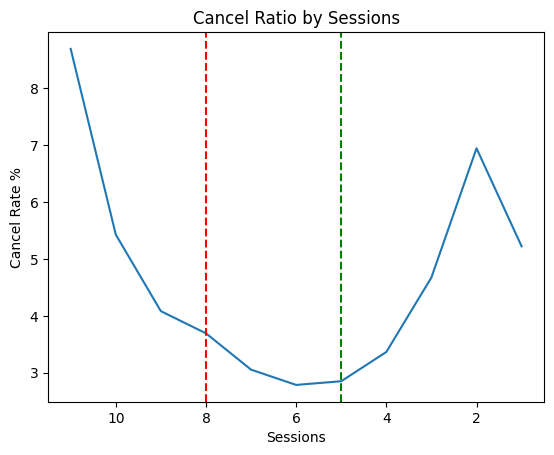

In [ ]:
# What about the cancel_rate? How do the users from the different sessions bucket behave?
plt.figure()

plt.plot(
    df_bucket['total_sessions'],
    df_bucket['cancel_rate']
)

plt.xlabel("Sessions")
plt.ylabel("Cancel Rate %")
plt.axvline(8, color='red', linestyle='--')
plt.axvline(5, color='green', linestyle='--')
plt.title("Cancel Ratio by Sessions")

plt.gca().invert_xaxis()

plt.show()

Users with more than 7 sessons tend to cancel more often than users with fewer sessions. Betwee 4 and 7 sessions we have the smaller cancel rate.

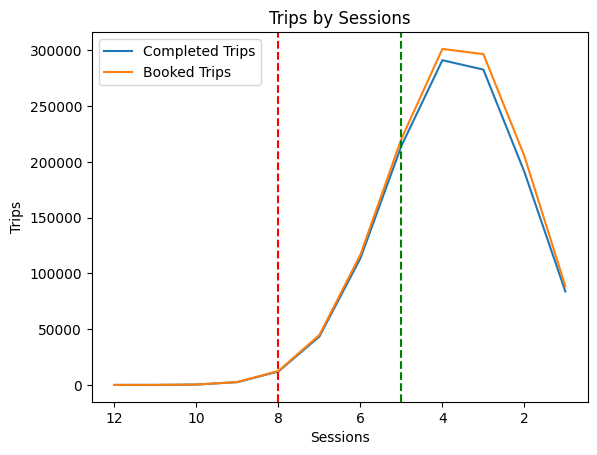

In [ ]:
# we have a small rate of cancelled trips, but which session bucket performs better
# in the acutal completed trips?
plt.plot(
    df_bucket['total_sessions'],
    df_bucket['total_completed_trips'],
    label='Completed Trips'
)

plt.plot(
    df_bucket['total_sessions'],
    df_bucket['total_trips'],
    label='Booked Trips'
)

plt.xlabel("Sessions")
plt.ylabel("Trips")
plt.axvline(8, color='red', linestyle='--')
plt.axvline(5, color='green', linestyle='--')
plt.title("Trips by Sessions")

plt.gca().invert_xaxis()

plt.legend()

plt.show()

Bookings that weren't cancelled. From Session > 7 we have less total of trips completed, yes we have less users, but the chart tell us that the bucket sessions 5 has a good chance to land a succesfull booking.

I defined a cutoff at users with ≥5 sessions to identify high-intent and high-value users.

This decision is based on several key observations:

* Revenue Concentration: Users with 5 or more sessions account for approximately 25% of total cumulative revenue, indicating a meaningful contribution despite being a smaller segment.
* User Quality: These users exhibit the lowest cancellation rates, particularly in the 5–6 session range, suggesting more reliable and committed booking behavior.
* Conversion Efficiency: The segment shows a conversion rate of around 40%, significantly higher than higher-session users, indicating stronger purchase intent.
* User Base Size: Importantly, this group still represents ~20% of the total user base, ensuring that the segment is large enough to be actionable for marketing and retention strategies.

Overall, this cutoff effectively balances revenue impact, behavioral quality, and segment size, making it a strong candidate for targeted business actions.

While ≥3 sessions captures a larger share of revenue, ≥5 sessions provides a cleaner segmentation of highly engaged and reliable users, with stronger behavioral signals such as lower cancellations and higher conversion rates.

## 2. EDA and FeaturePrep with "user_features"

We built the `user_features` table through a structured pipeline designed to capture user behavior, engagement, and value at a consistent user level. The process started with the creation of a clean `trips` table, where we consolidated booking information from sessions, flights, and hotels into a single trip-level dataset. During this step, we carefully handled data quality issues by removing inconsistent records, correcting invalid values, and ensuring that revenue and timing variables were logically consistent.

Once the trips table was validated, we aggregated both session-level and trip-level data to the user level. This allowed us to construct features that describe user engagement, such as total sessions and interaction metrics, as well as transactional behavior, including number of trips, revenue, and conversion-related measures. We also derived efficiency metrics like revenue per session to better understand user performance.

Special attention was given to handling missing values in a way that preserves their meaning, distinguishing between users with no activity and users with zero outcomes. Finally, we engineered composite indices to summarize complex behavior, such as activity and value, using log transformations to stabilize distributions.

To focus the analysis on meaningful behavior, we defined a cohort of users with at least five sessions. This threshold isolates users with clear purchase intent, higher conversion rates, lower cancellation behavior, and a significant contribution to overall revenue. The resulting dataset provides a clean and robust foundation for exploratory analysis, segmentation, and machine learning applications.


In [ ]:
df = pd.read_csv('/content/user_features.csv')
df.shape
df.info()
df.head()

FileNotFoundError: [Errno 2] No such file or directory: '/content/user_features.csv'

I've created in SQL the following indices to reduce the dimesionality of my features, I've added them to my 'user_features' table:
 * value_index =  avg_revenue_per_trip * total_trips * revenue_per_session
 * activity_index = total_sessions * avg_page_clicks * avg_session_duration_minutes
 * quality_index = conversion_rate * total_sessions * avg_revenue_per_trip

In [ ]:
df_prep = df.copy()

# create flags two easily identify the users with no activity later on, 'til now I had the NULL values to identify users with no bookings, and no revenue but
# later on Ill have to turn those NULL into 0, that's why I've created this flags two simplify the filtering
df_prep['has_trips'] = df_prep['total_trips'] > 0
df_prep['has_revenue'] = df_prep['total_revenue'] > 0

print("Descriptive Statistics:")
print(df_prep.info())

print("\nMissing Values:")
print(df_prep.isnull().sum())

In [ ]:
print("Descriptive Statistics:")
print(df_prep.describe().T)

In [ ]:
df_prep.head()

In [ ]:
# I want to see how the quality Index performs
plt.figure()

df_prep['quality_index'].hist(bins=50)

plt.title("Quality Index")
plt.xlabel("Revenue per Trip")
plt.ylabel("Frequency")

plt.show()

In [ ]:
# I want to see how the quality Index performs
plt.figure()

df_prep['value_index'].hist(bins=50)

plt.title("Quality Index")
plt.xlabel("Revenue per Trip")
plt.ylabel("Frequency")

plt.show()

In [ ]:
# I want to see how is the revenue distributon across all users
plt.figure()

df_prep[
    (df_prep['has_trips']) & (df_prep['has_revenue'])
]['avg_revenue_per_trip'].hist(bins=50)

plt.title("Avg Revenue per Trip (Valid Users)")
plt.xlabel("Revenue per Trip")
plt.ylabel("Frequency")

plt.show()

We have a few users with big amount of revenue that are skewing the dataset. Also we have many user with 0 value, those are the users without bookings(0 revenue)

## 3. Segmentation

In [ ]:
# select all the users with no bookings and take a closer look
df_no_purchase = df_prep[(df_prep['total_sessions'] > 0) & (df_prep['has_trips'] == False)]

df_no_purchase.shape[0]

df_no_purchase.info()

df_prep.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
Index: 20119 entries, 3 to 189430
Data columns (total 31 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   user_id                       20119 non-null  int64  
 1   total_sessions                20119 non-null  int64  
 2   conversion_rate               0 non-null      float64
 3   avg_page_clicks               20119 non-null  float64
 4   total_page_clicks             20119 non-null  int64  
 5   avg_session_duration_minutes  20119 non-null  float64
 6   last_session                  20119 non-null  object 
 7   total_trips                   20119 non-null  int64  
 8   completed_trips               20119 non-null  int64  
 9   trips_per_session             20119 non-null  float64
 10  total_revenue                 20119 non-null  float64
 11  avg_revenue_per_trip          0 non-null      float64
 12  revenue_per_session           20119 non-null  float64
 13  avg_t

,0
user_id,0
total_sessions,0
conversion_rate,20119
avg_page_clicks,0
total_page_clicks,0
avg_session_duration_minutes,0
last_session,0
total_trips,0
completed_trips,0
trips_per_session,0


In [ ]:
# which perc represtents the users with no bookings
print(df_no_purchase.shape[0])
print(df_prep.shape[0])
print(df_no_purchase.shape[0] / df_prep.shape[0] * 100)

20119
189432
10.620697664597323


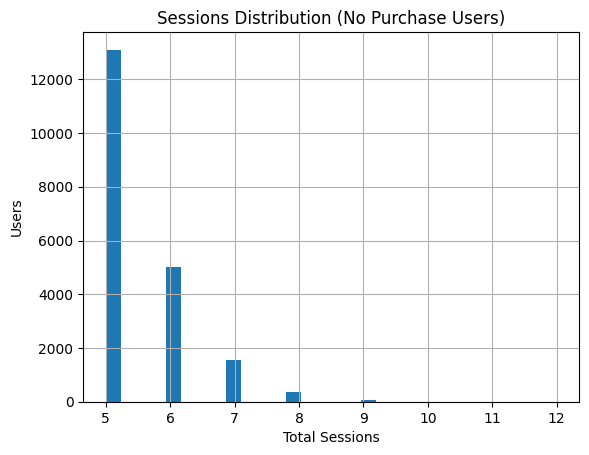

In [ ]:
plt.figure()

df_no_purchase['total_sessions'].hist(bins=30)

plt.title("Sessions Distribution (No Purchase Users)")
plt.xlabel("Total Sessions")
plt.ylabel("Users")

plt.show()

In [ ]:
# quick comparison purchse vs no purchase
df_purchase = df_prep[df_prep['has_trips'] == True]

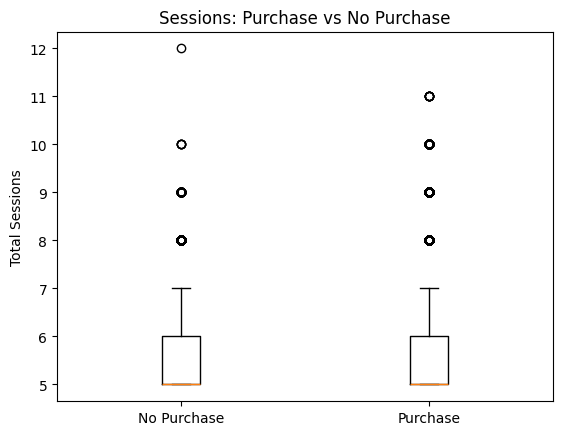

In [ ]:
# quick comparison purchse vs no purchase
df_purchase = df_prep[df_prep['has_trips'] == True]

plt.figure()

plt.boxplot([
    df_no_purchase['total_sessions'],
    df_purchase['total_sessions']
])

plt.xticks([1,2], ['No Purchase', 'Purchase'])
plt.ylabel("Total Sessions")
plt.title("Sessions: Purchase vs No Purchase")

plt.show()

In [ ]:
# Sessions behavior of user with booking vs without bookings
print(df_no_purchase['total_sessions'].mean())
print(df_purchase['total_sessions'].mean())

5.475023609523336
5.577947351945805


In [ ]:
df_prep['has_trips'].value_counts(normalize=True)

,proportion
has_trips,
True,0.893793
False,0.106207


In [ ]:
print(df_no_purchase['total_sessions'].describe())

count    20119.000000
mean         5.475024
std          0.751219
min          5.000000
25%          5.000000
50%          5.000000
75%          6.000000
max         12.000000
Name: total_sessions, dtype: float64


A significant portion of users (~10%) engage actively with the platform but never convert, despite exhibiting a similar level of activity (avg. ~5.5 sessions) as purchasing users.

User activity alone is not a reliable predictor of conversion. A subset of highly engaged users fails to convert, indicating friction or barriers in the booking process.

I'm going to create my first segment out of it and assign them the "First-Booking Discount" Perk

<Axes: >

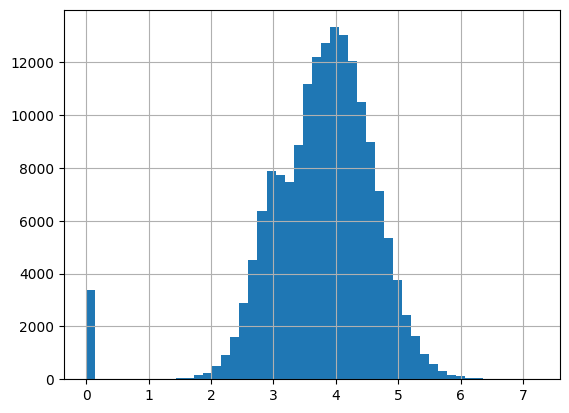

In [ ]:
df_purchase['quality_index'].hist(bins=50)

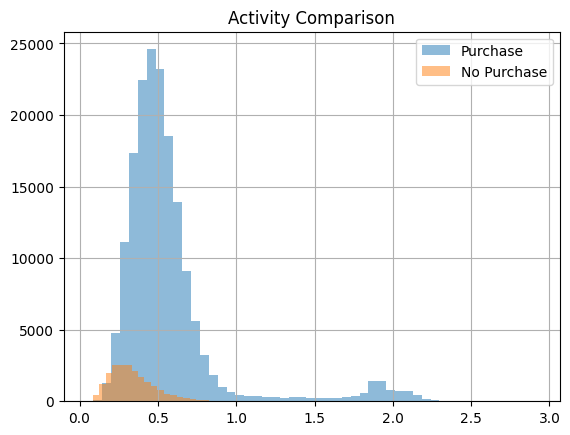

In [ ]:
plt.figure()

df_purchase['activity_index'].hist(bins=50, alpha=0.5)
df_no_purchase['activity_index'].hist(bins=50, alpha=0.5)

plt.legend(['Purchase', 'No Purchase'])
plt.title("Activity Comparison")

plt.show()

In [ ]:
#validating that the segmentation works correctly
print(df_purchase.shape[0] + df_no_purchase.shape[0])
print(len(df_prep))

189432
189432


EDA continues

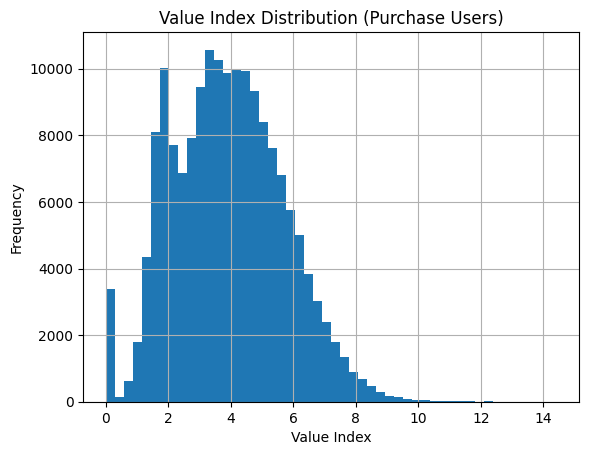

In [ ]:
plt.figure()

df_purchase['value_index'].hist(bins=50)

plt.title("Value Index Distribution (Purchase Users)")
plt.xlabel("Value Index")
plt.ylabel("Frequency")

plt.show()

In [ ]:
df_purchase['value_index'].describe()

,value_index
count,169313.000000
mean,3.912273
std,1.782771
min,0.000000
25%,2.569460
50%,3.849950
75%,5.127790
max,14.420213


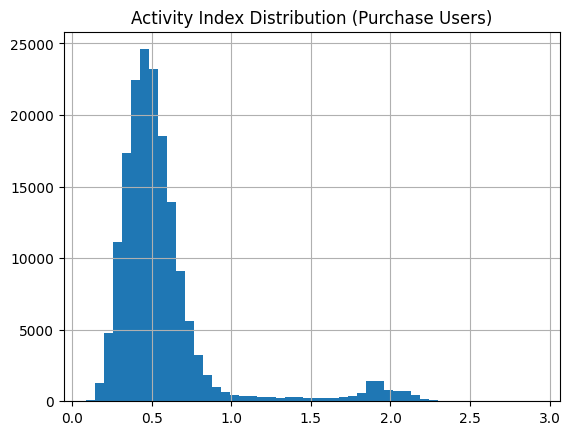

In [ ]:
plt.figure()

df_purchase['activity_index'].hist(bins=50)

plt.title("Activity Index Distribution (Purchase Users)")
plt.show()

In [ ]:
df_purchase['activity_index'].describe()

,activity_index
count,169313.000000
mean,0.569611
std,0.346715
min,0.088696
25%,0.392817
50%,0.491802
75%,0.611058
max,2.920723


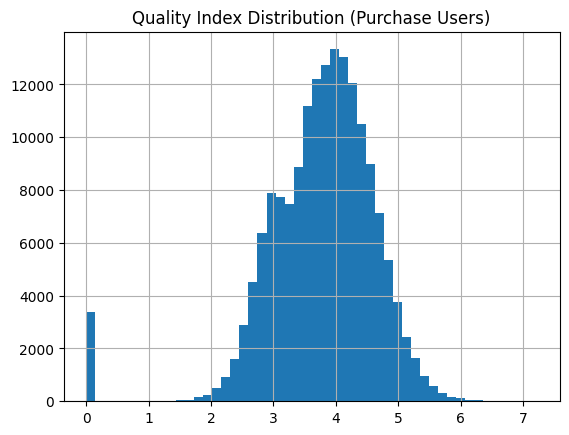

In [ ]:
plt.figure()

df_purchase['quality_index'].hist(bins=50)

plt.title("Quality Index Distribution (Purchase Users)")
plt.show()

In [ ]:
df_purchase['quality_index'].describe()

,quality_index
count,169313.000000
mean,3.766653
std,0.886635
min,0.000000
25%,3.296671
50%,3.855944
75%,4.332087
max,7.226366


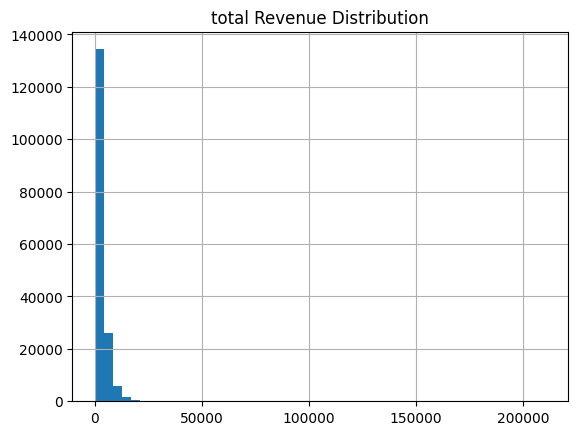

In [ ]:
plt.figure()

df_purchase['total_revenue'].hist(bins=50)

plt.title("total Revenue Distribution")
plt.show()

Now I want to deal with those users with high amount of revenue

In [ ]:
df_purchase['total_revenue'].describe()

,total_revenue
count,169313.000000
mean,3029.295506
std,4113.130795
min,0.000000
25%,1059.520000
50%,2071.250000
75%,3734.870000
max,210617.360000


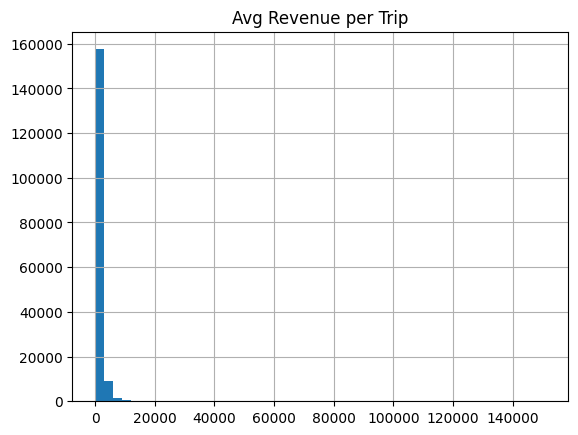

In [ ]:
plt.figure()

df_purchase['avg_revenue_per_trip'].hist(bins=50)

plt.title("Avg Revenue per Trip")
plt.show()

They could only be considered outliers but I want too take a closer look

In [ ]:
df_purchase['avg_revenue_per_trip'].describe()

,avg_revenue_per_trip
count,169313.000000
mean,1343.908861
std,2161.530552
min,0.000000
25%,583.130000
50%,893.270000
75%,1473.760000
max,151108.640000


In [ ]:
print(df_purchase['avg_revenue_per_trip'].quantile(0.95))

3578.485999999999


In [ ]:
threshold = df_purchase['total_revenue'].quantile(0.95)
df_high_value = df_purchase[df_purchase['total_revenue'] > threshold]

In [ ]:
df_normal = df_purchase[df_purchase['total_revenue'] <= threshold]

In [ ]:
df_high_value.shape[0] / df_purchase.shape[0] * 100

5.000206717735791

High value users are the one responsible of big part of the revenue. Althoguh they repreent the 5% it is important for the company to keep those users or rectivete them.

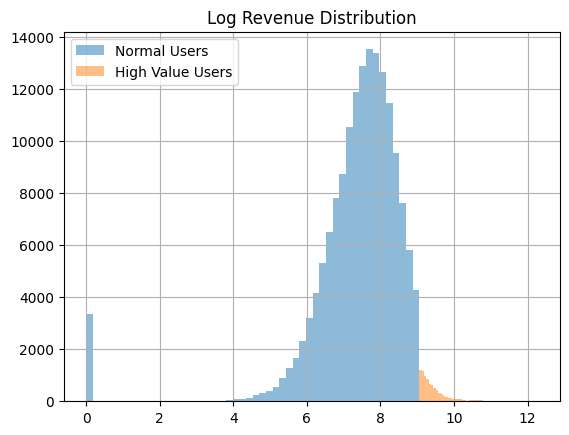

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

plt.figure()

np.log1p(df_normal['total_revenue']).hist(bins=50, alpha=0.5)
np.log1p(df_high_value['total_revenue']).hist(bins=50, alpha=0.5)

plt.legend(['Normal Users', 'High Value Users'])
plt.title("Log Revenue Distribution")

plt.show()

In [ ]:
print('high value user')
print(df_high_value['activity_index'].mean())
print(df_high_value['quality_index'].mean())
print(df_high_value['conversion_rate'].mean())
print("standard user")
print(df_normal['activity_index'].mean())
print(df_normal['quality_index'].mean())
print(df_normal['conversion_rate'].mean())

high value user
0.5549088901128973
5.060672252130349
53.80564611386723
standard user
0.570384537219846
3.698544006401277
40.09400523478834


A small subset of users (top 5%) contributes disproportionately to total revenue, indicating a high-value segment with distinct behavioral characteristics. I'll create a anew segment out of this group

We identified a high-value segment representing the top 5% of users by total revenue, who exhibit higher conversion rates, stronger engagement, and superior overall quality scores. This group will be treated as a priority segment due to its disproportionate contribution to business performance.

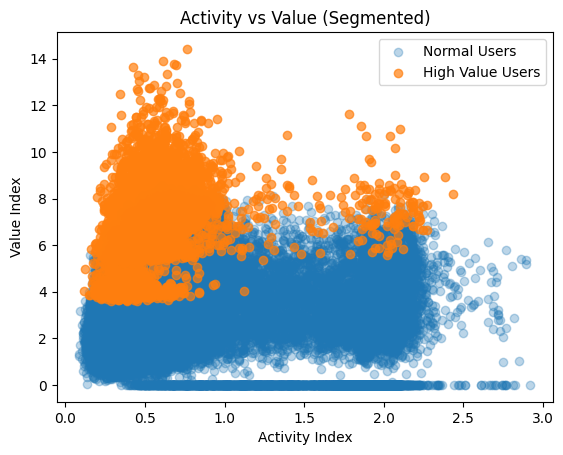

In [ ]:
plt.figure()

plt.scatter(
    df_normal['activity_index'],
    df_normal['value_index'],
    alpha=0.3,
    label='Normal Users'
)

plt.scatter(
    df_high_value['activity_index'],
    df_high_value['value_index'],
    alpha=0.7,
    label='High Value Users'
)

plt.xlabel("Activity Index")
plt.ylabel("Value Index")
plt.title("Activity vs Value (Segmented)")

plt.legend()

Given that this segment is less price-sensitive and demonstrates high purchasing efficiency, the recommended strategy is to focus on experience rather than discounts. Offering priority access, personalized assistance, and a frictionless booking experience is more likely to drive retention and reactivation than traditional monetary incentives.

## 4. ML Clustering

In [ ]:
features = ['activity_index', 'value_index', 'quality_index']

X = df_normal[features]

X = X.fillna(0)

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

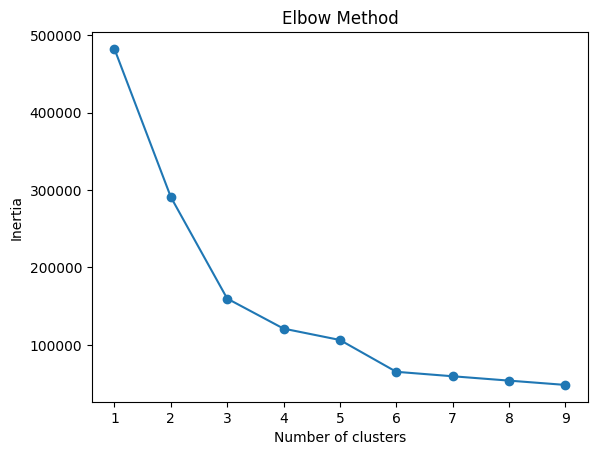

In [ ]:
from sklearn.cluster import KMeans

inertia = []

for k in range(1, 10):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure()
plt.plot(range(1,10), inertia, marker='o')
plt.xlabel("Number of clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

In [ ]:
df_normal = df_purchase[df_purchase['total_revenue'] <= threshold].copy()

In [ ]:
kmeans = KMeans(n_clusters=4, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

df_normal['cluster'] = clusters

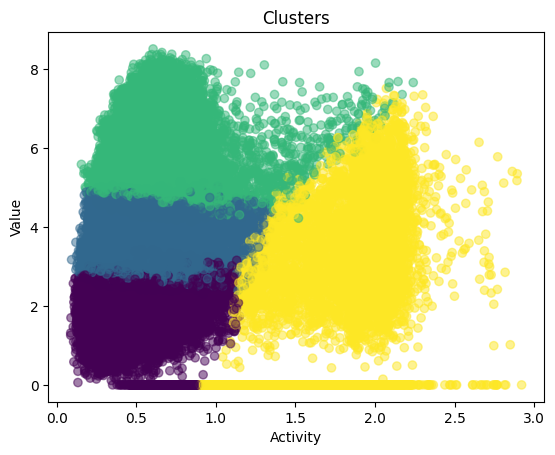

In [ ]:
plt.figure()

plt.scatter(
    df_normal['activity_index'],
    df_normal['value_index'],
    c=df_normal['cluster'],
    alpha=0.5
)

plt.xlabel("Activity")
plt.ylabel("Value")
plt.title("Clusters")

plt.show()

In [ ]:
df_normal.groupby('cluster')[features].mean()

,activity_index,value_index,quality_index
cluster,,,
0,0.414087,1.910895,2.948397
1,0.488127,3.753901,3.826551
2,0.582132,5.704526,4.528381
3,1.818948,2.378634,2.129351


## 5. Validation


I missed checking the correlation of the features that I use to calculate the indices. If there is a correlation between features I'll have to recalculate my indices.

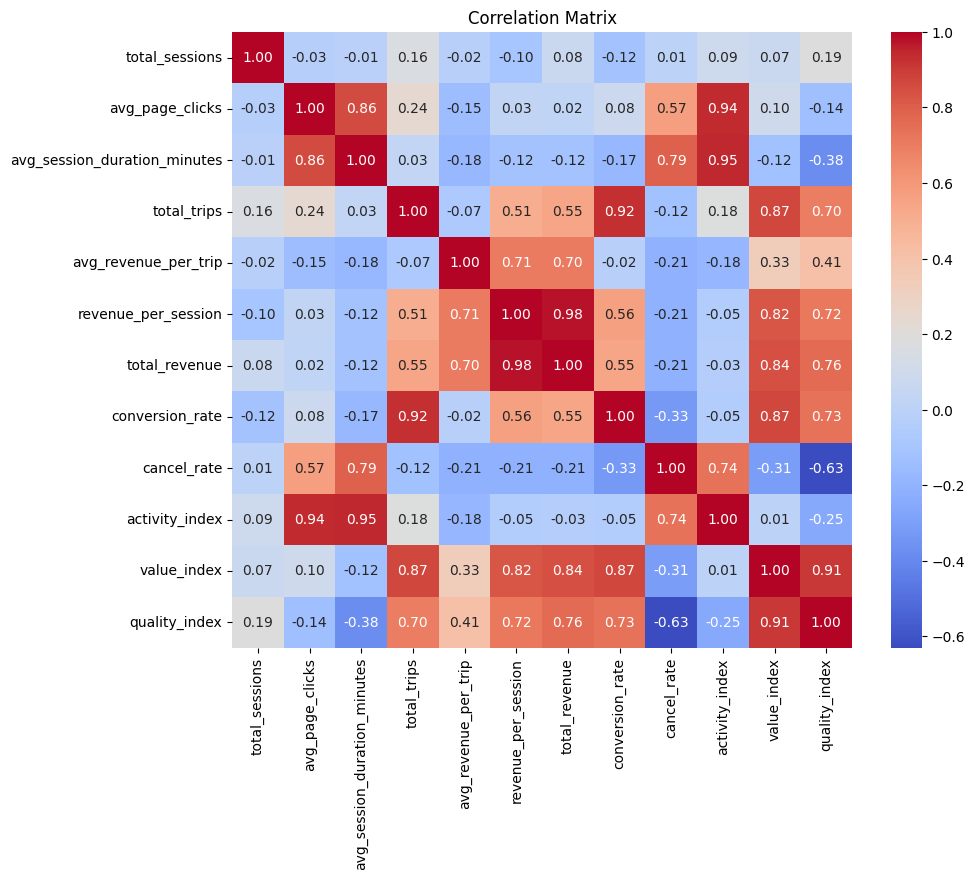

In [ ]:
corr_features = [
    'total_sessions',
    'avg_page_clicks',
    'avg_session_duration_minutes',

    'total_trips',
    'avg_revenue_per_trip',
    'revenue_per_session',
    'total_revenue',

    'conversion_rate',
    'cancel_rate',

    'activity_index',
    'value_index',
    'quality_index'
]
# create df
corr_df = df_normal[corr_features]
# missing values
corr_df = corr_df.fillna(0)
#corr matrix
corr_matrix = corr_df.corr()

#Dispaly matrix
import seaborn as sns

plt.figure(figsize=(10,8))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Matrix")

plt.show()

A strong correlation exist between many features that made my indices and between the indices self. I'll recalculate the indices for a better clustering result.

## 6. Import new dataset

In [ ]:
# I've reimported the user_features table but this time I didn't include the indices
# 'cos I'm going to claculate them in python.
#Also I've included the columns seats, checked_bags, rooms and nights. I think
# they are important for clustering
#Also I'm goin to keep the segmenes that I've already found "no bookings" and "high value"

import pandas as pd
import numpy as np

df = pd.read_csv('/content/user_features_v02.csv')
df.shape
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 189432 entries, 0 to 189431
Data columns (total 29 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   user_id                       189432 non-null  int64  
 1   total_sessions                189432 non-null  int64  
 2   conversion_rate               169313 non-null  float64
 3   avg_page_clicks               189432 non-null  float64
 4   total_page_clicks             189432 non-null  int64  
 5   avg_session_duration_minutes  189432 non-null  float64
 6   last_session                  189432 non-null  object 
 7   total_trips                   189432 non-null  int64  
 8   completed_trips               189432 non-null  int64  
 9   trips_per_session             189432 non-null  float64
 10  total_revenue                 189432 non-null  float64
 11  avg_revenue_per_trip          169313 non-null  float64
 12  revenue_per_session           189432 non-nul

,user_id,total_sessions,conversion_rate,avg_page_clicks,total_page_clicks,avg_session_duration_minutes,last_session,total_trips,completed_trips,trips_per_session,...,cancel_rate,one_way_ratio,discount_ratio,flight_ratio,hotel_ratio,avg_distance_km,account_age_days,age,has_children,married
0,134,5,0.4,18.4,92,2.28,2023-07-19 17:03:39.000,2,2,0.4,...,0.0,0.0,0.00,0.5,1.0,1652.0,877,35,True,False
1,453,5,0.6,15.4,77,1.92,2023-05-17 12:42:14.000,3,3,0.6,...,0.0,0.0,0.33,1.0,1.0,1492.0,865,28,False,False
2,519,5,0.2,8.2,41,1.02,2023-06-11 18:13:15.000,1,1,0.2,...,0.0,0.0,0.00,1.0,1.0,2166.0,864,45,False,False
3,577,5,NaN,11.4,57,1.41,2023-06-05 17:03:28.000,0,0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,863,41,False,False
4,638,5,NaN,10.0,50,1.25,2023-03-20 11:30:16.000,0,0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,858,21,False,False


In [ ]:
#next I create again the flags "has_trips" and "has_revenue" for filtering later
df['has_trips'] = df['total_trips'] > 0
df['has_revenue'] = df['total_revenue'] > 0
# I think this two flags could be redundant but I want to bulletproof the filteres :)

## 7. First Segmentation

In [ ]:
# create the segment "no purchase" for user with al lest 5 sessions
# and still not a completed trip

df_no_purchase = df[(df['has_trips'] == False) & (df['has_revenue'] == False)].copy()

In [ ]:
# I create the second segment "high value" = quntile -> 0.95
threshold = df[df['has_revenue']]['total_revenue'].quantile(0.95)

df_high_value = df[(df['total_revenue'] > threshold)].copy()

In [ ]:
#remove both segments from the rest of the dataset
df_model = df[(df['has_trips'] == True) & (df['has_revenue'] == True) & (df['total_revenue'] <= threshold)].copy()

In [ ]:
# quick check of the three segments
print(df.shape)
print(df_model.shape)
print(df_no_purchase.shape)
print(df_high_value.shape)
print(df_model.shape[0] + df_no_purchase.shape[0] + df_high_value.shape[0])

(189432, 31)
(157652, 31)
(20119, 31)
(8297, 31)
186068


In [ ]:
# Identify the missing segment: users with trips but no revenue
df_trips_no_revenue = df[(df['total_trips'] > 0) & (df['total_revenue'] == 0)].copy()

print(f"Number of users with trips but no revenue: {df_trips_no_revenue.shape[0]}")

Number of users with trips but no revenue: 3364


In [ ]:
# I've noticed that 3364 users were missing. Those are users with bookings but no revenue
# Lookind at the cancel_rate I find out why.
df_trips_no_revenue['cancel_rate'].describe()

,cancel_rate
count,3364.000000
mean,0.999703
std,0.017241
min,0.000000
25%,1.000000
50%,1.000000
75%,1.000000
max,1.000000


In [ ]:
# I noticed something wrong on the table above "cancel:Rate" is a binary column
# df_trips_no_revenue should have only cancel_rate =1 and std = 0
display(df_trips_no_revenue[df_trips_no_revenue['cancel_rate'] < 1].head().T)

,6871
user_id,251737
total_sessions,5
conversion_rate,0.2
avg_page_clicks,16.8
total_page_clicks,84
avg_session_duration_minutes,2.09
last_session,2023-05-06 13:51:27.000
total_trips,1
completed_trips,1
trips_per_session,0.2


In [ ]:
# df_trips_no_revenue should have only completed_trips = 0 and std = 0
df_trips_no_revenue['completed_trips'].describe()

,completed_trips
count,3364.000000
mean,0.000297
std,0.017241
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,1.000000


In [ ]:
# This user has a competed trip with 0 revenue, no discounts, not cancelled,
# Clearly is an error and I going t delete it.
display(df_trips_no_revenue[df_trips_no_revenue['completed_trips'] > 0].head().T)

,6871
user_id,251737
total_sessions,5
conversion_rate,0.2
avg_page_clicks,16.8
total_page_clicks,84
avg_session_duration_minutes,2.09
last_session,2023-05-06 13:51:27.000
total_trips,1
completed_trips,1
trips_per_session,0.2


In [ ]:
# I'm goin to keep the users with booking but without revenue
#Those are users that cancelled their trips.
# Quick sanity checks
len(df) == (
    len(df_no_purchase) +
    len(df_high_value) +
    len(df_model) +
    len(df_trips_no_revenue) +
    1 # deleted user
)

False

In [ ]:
# Sanity check 2
df_no_purchase['user_id'].isin(df_model['user_id']).sum()
df_high_value['user_id'].isin(df_model['user_id']).sum()
df_trips_no_revenue['user_id'].isin(df_model['user_id']).sum()

np.int64(0)

## 8. Feature Preparation

In [ ]:
# Now Im goin to use the rest of the data to make a clustering with ML.
# First I'll create a correlation Matrix
# Need to prepeare the data for the matrix first
df_corr = df_model.copy()

# convert "last_session" to datetime and calculate "days_since_last_session"
df_corr['last_session'] = pd.to_datetime(df_corr['last_session'])

# Las day of the last month of our dataset
reference_date = pd.to_datetime('2023-07-31')
df_corr['days_since_last_session'] = (reference_date - df_corr['last_session']).dt.days


# we don't these coulmns anymmore
df_corr = df_corr.drop(columns = ['user_id', 'has_trips', 'has_revenue', 'last_session'])

#convert features to numeric
df_corr = df_corr.apply(pd.to_numeric, errors='coerce')

# Inpute NaN valuees with 0
df_corr = df_corr.fillna(0)

# describe the result
df_corr.shape
df_corr.info()
df_corr.head()


<class 'pandas.core.frame.DataFrame'>
Index: 157652 entries, 0 to 189431
Data columns (total 28 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   total_sessions                157652 non-null  int64  
 1   conversion_rate               157652 non-null  float64
 2   avg_page_clicks               157652 non-null  float64
 3   total_page_clicks             157652 non-null  int64  
 4   avg_session_duration_minutes  157652 non-null  float64
 5   total_trips                   157652 non-null  int64  
 6   completed_trips               157652 non-null  int64  
 7   trips_per_session             157652 non-null  float64
 8   total_revenue                 157652 non-null  float64
 9   avg_revenue_per_trip          157652 non-null  float64
 10  revenue_per_session           157652 non-null  float64
 11  avg_lead_time                 157652 non-null  float64
 12  avg_trip_duration             157652 non-null  fl

,total_sessions,conversion_rate,avg_page_clicks,total_page_clicks,avg_session_duration_minutes,total_trips,completed_trips,trips_per_session,total_revenue,avg_revenue_per_trip,...,one_way_ratio,discount_ratio,flight_ratio,hotel_ratio,avg_distance_km,account_age_days,age,has_children,married,days_since_last_session
0,5,0.4,18.4,92,2.28,2,2,0.4,1094.49,547.25,...,0.0,0.00,0.5,1.0,1652.0,877,35,True,False,11
1,5,0.6,15.4,77,1.92,3,3,0.6,3110.63,1036.88,...,0.0,0.33,1.0,1.0,1492.0,865,28,False,False,74
2,5,0.2,8.2,41,1.02,1,1,0.2,570.77,570.77,...,0.0,0.00,1.0,1.0,2166.0,864,45,False,False,49
5,5,0.4,26.4,132,3.25,2,2,0.4,1385.95,692.98,...,0.0,0.50,1.0,0.5,3708.0,848,53,False,True,119
6,5,0.4,31.0,155,3.85,2,2,0.4,1897.57,948.79,...,0.0,0.00,1.0,1.0,1158.0,848,16,False,False,28


In [ ]:
#Now the corr matrix
corr_matrix = df_corr.corr()

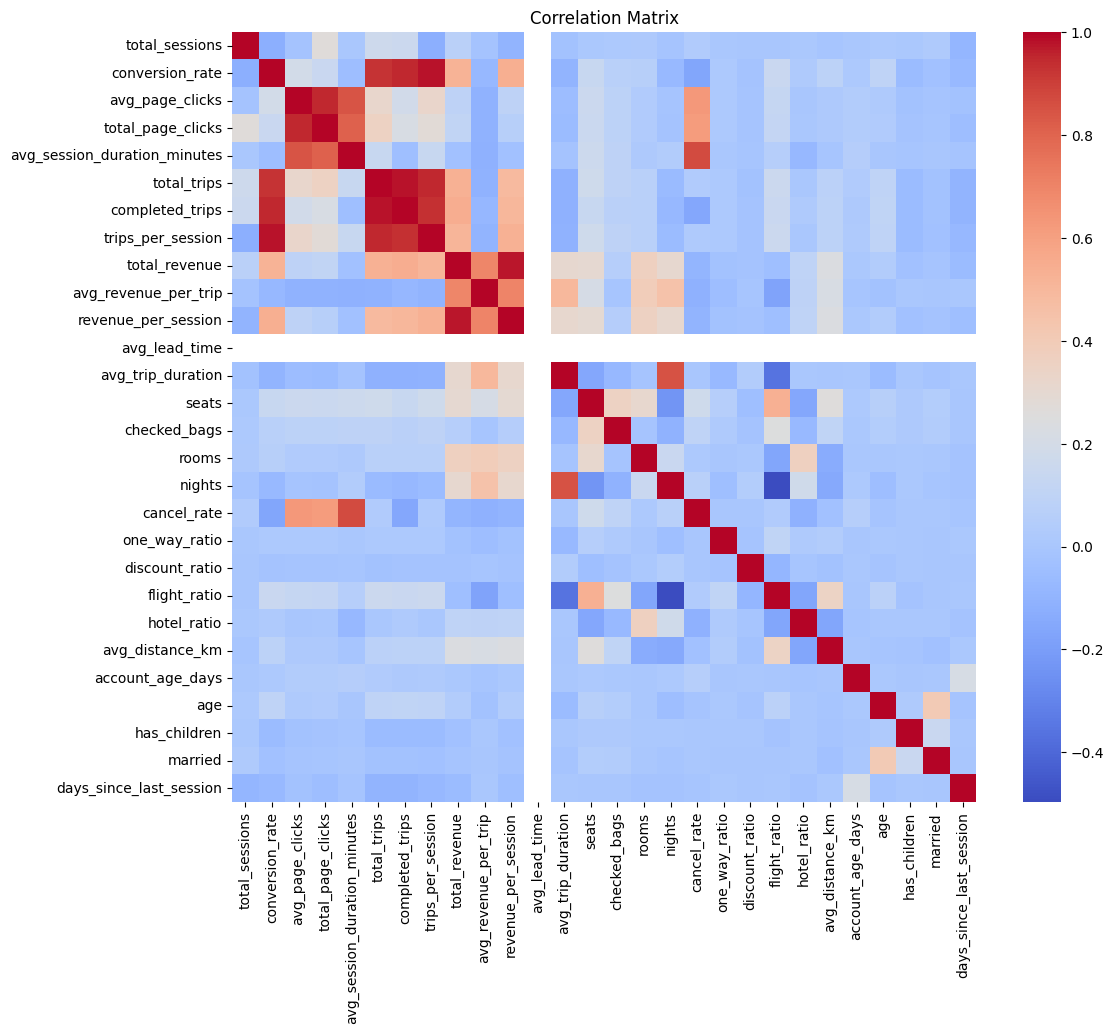

In [ ]:
# and make a visual
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,10))

sns.heatmap(corr_matrix, annot=False, cmap='coolwarm')

plt.title("Correlation Matrix")

plt.show()

In [ ]:
corr_matrix.unstack().sort_values(ascending=False).drop_duplicates().head(20)

,,0
days_since_last_session,days_since_last_session,1.000000
trips_per_session,conversion_rate,0.979677
completed_trips,total_trips,0.979582
total_revenue,revenue_per_session,0.976252
conversion_rate,completed_trips,0.951475
total_page_clicks,avg_page_clicks,0.949116
total_trips,trips_per_session,0.948861
completed_trips,trips_per_session,0.932087
conversion_rate,total_trips,0.927970
avg_session_duration_minutes,cancel_rate,0.866796


In [ ]:
#Now i'll create the indices using:
# value_index = (flight_ratio * hotel_ratio)* avg_revenue_per_trip * conversion_rate * avg_distance_km
# engagement_index = recency * avg_page_clicks * revenue_per_session
# consistenc_index = completed_trips * cancel_rate * account_age_days

df_prep = df_corr.copy()

#first value_index
df_prep['all_inclusive'] = (df_prep['flight_ratio'] * df_prep['hotel_ratio']) #create all inclusive column

df_prep['value_index'] = (
    np.log1p(df_prep['avg_revenue_per_trip']) *
    np.log1p(df_prep['conversion_rate']) *
    np.log1p(df_prep['avg_distance_km']) *
    np.log1p(df_prep['all_inclusive']))

# for the engagement_index I need to calculate
# first the recency: higher recency = less days since last session
df_prep['recency'] = 1 / (1 + df_prep['days_since_last_session'])

# now the engagement_index
df_prep['engagement_index'] = (
    np.log1p(df_prep['revenue_per_session']) *
    np.log1p(df_prep['avg_page_clicks']) *
    np.log1p(df_prep['recency'])
)

# now the consistency_index
df_prep['consistency_index'] = (
    np.log1p(df_prep['completed_trips']) *
    np.log1p(df_prep['account_age_days']) *
    (1 - df_corr['cancel_rate'])
)

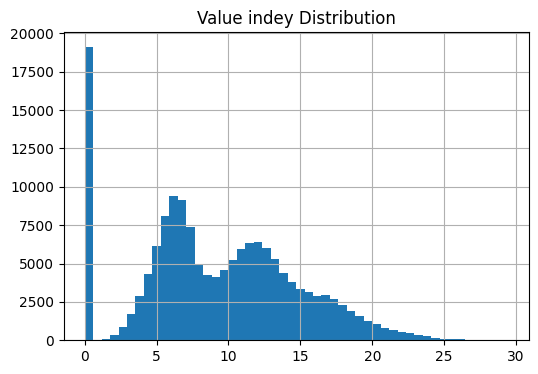

In [ ]:
# now I validate the indices, with a distribution visualzation

plt.figure(figsize=(6,4))
df_prep['value_index'].hist(bins=50)
plt.title("Value indey Distribution")
plt.show()

In [ ]:
# Hm the distribution doesn't looks good... too many 0's I'll check why is that

In [ ]:
# Select data points with value_index < 1
df_low_value_index = df_prep[df_prep['value_index'] < 1].copy()

# Display the first 10 rows of the filtered DataFrame

columns_to_display = [
    'avg_revenue_per_trip',
    'conversion_rate',
    'avg_distance_km',
    'flight_ratio',
    'hotel_ratio',
    'all_inclusive',
    'cancel_rate',
    'completed_trips',
    'value_index'
]

display(df_low_value_index[columns_to_display].head(10))

# Display the shape of the filtered DataFrame
print(f"Shape of DataFrame with value_index < 1: {df_low_value_index.shape}")

,avg_revenue_per_trip,conversion_rate,avg_distance_km,flight_ratio,hotel_ratio,all_inclusive,cancel_rate,completed_trips,value_index
8,3760.00,0.2,0.0,0.0,1.0,0.00,0.0,1,0.0
43,833.00,0.2,0.0,0.5,0.5,0.25,0.5,1,0.0
51,340.00,0.2,0.0,0.0,1.0,0.00,0.0,1,0.0
57,1036.80,0.2,0.0,0.0,1.0,0.00,0.0,1,0.0
72,437.40,0.2,0.0,0.0,1.0,0.00,0.0,1,0.0
73,1273.50,0.2,0.0,0.0,1.0,0.00,0.0,1,0.0
83,2418.00,0.2,0.0,0.0,1.0,0.00,0.0,1,0.0
100,269.44,0.2,1651.0,1.0,0.0,0.00,0.0,1,0.0
105,853.50,0.4,0.0,0.0,1.0,0.00,0.0,2,0.0
119,840.00,0.2,0.0,0.0,1.0,0.00,0.0,1,0.0


Shape of DataFrame with value_index < 1: (19121, 33)


In [ ]:
# there are too many 0's in the varibales that make the index,
# avg_distance_km, all_inclusive(flight_ratio * hotel_ratio)

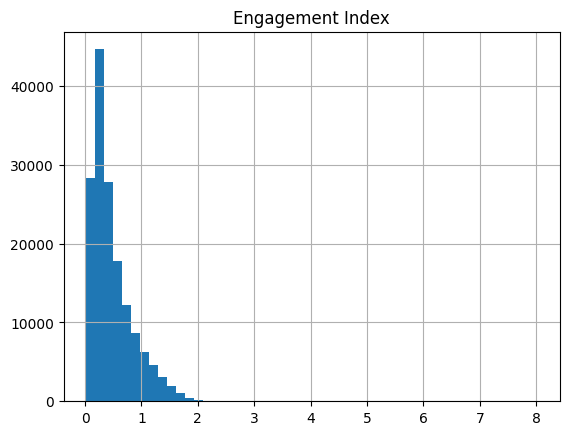

In [ ]:
plt.figure()
df_prep['engagement_index'].hist(bins=50)
plt.title("Engagement Index")
plt.show()

In [ ]:
# very long tailed distribution

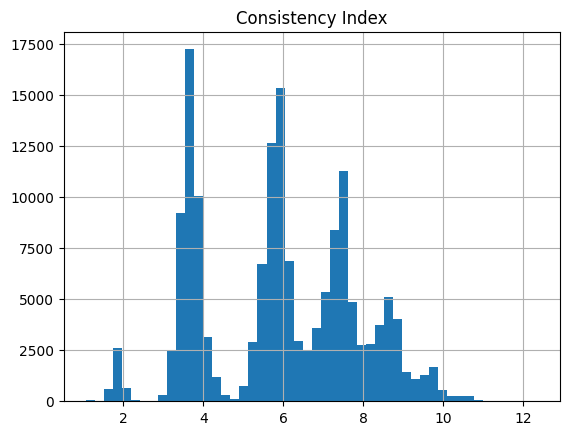

In [ ]:
plt.figure()
df_prep['consistency_index'].hist(bins=50)
plt.title("Consistency Index")
plt.show()

In [ ]:
# those speaks doesn't look good,
# I'll try anew math to calculate the indices add insted multiply

In [ ]:
df_prep['value_index'] = (
    np.log1p(df_prep['avg_revenue_per_trip']) +
    df_prep['conversion_rate'] +
    np.log1p(df_prep['avg_distance_km']) +
    df_prep['all_inclusive']
)

df_prep['engagement_index'] = (
    np.log1p(df_prep['revenue_per_session']) +
    np.log1p(df_prep['avg_page_clicks']) +
    df_prep['recency']
)

df_prep['consistency_index'] = (
    np.log1p(df_prep['completed_trips']) +
    (1 - df_prep['cancel_rate']) +
    np.log1p(df_prep['account_age_days']) +
    df_prep['all_inclusive']
)

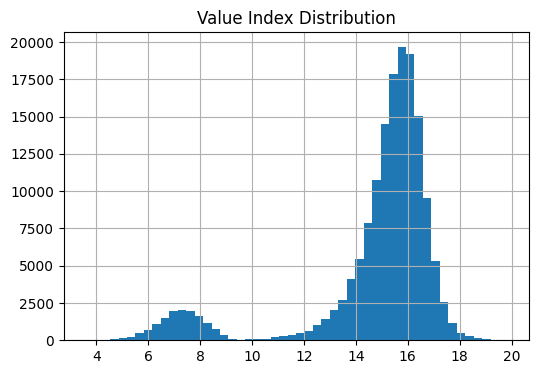

In [ ]:
plt.figure(figsize=(6,4))
df_prep['value_index'].hist(bins=50)
plt.title("Value Index Distribution")
plt.show()

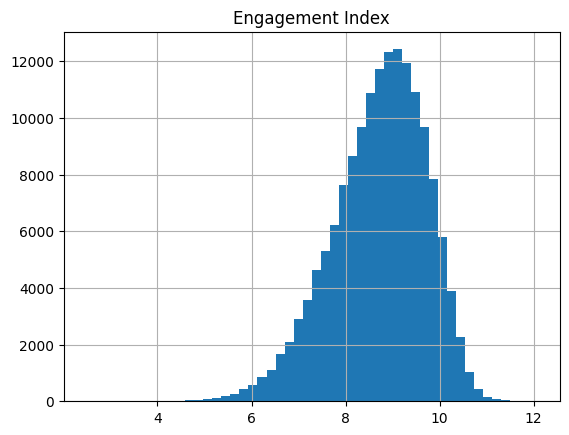

In [ ]:
plt.figure()
df_prep['engagement_index'].hist(bins=50)
plt.title("Engagement Index")
plt.show()

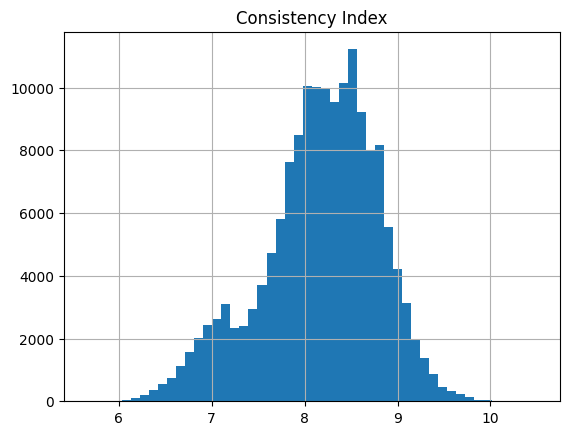

In [ ]:
plt.figure()
df_prep['consistency_index'].hist(bins=50)
plt.title("Consistency Index")
plt.show()

In [ ]:
# I think that works better, now clustering

## 9. Clustering with indices

In [ ]:
features = [
    'value_index',
    'engagement_index',
    'consistency_index'
]

X = df_prep[features].copy()

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

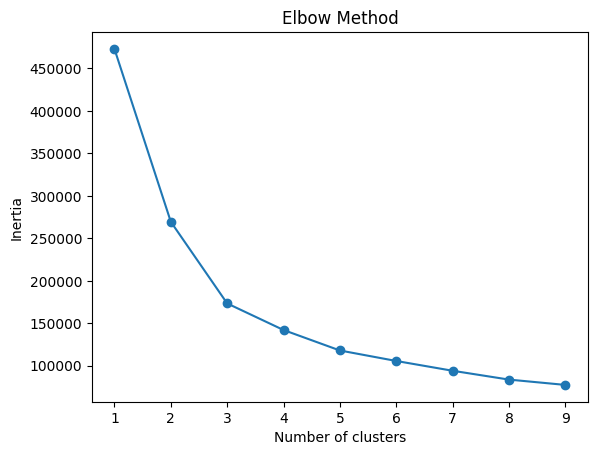

In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

for k in range(1, 10):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure()
plt.plot(range(1,10), inertia, marker='o')
plt.xlabel("Number of clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

In [ ]:
# I think 3 is the right number of clusters

In [ ]:
from sklearn.metrics import silhouette_score
'''
for k in range(2, 10):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    print(f"k={k}, silhouette={score:.3f}")
'''

'\nfor k in range(2, 10):\n    kmeans = KMeans(n_clusters=k, random_state=42)\n    labels = kmeans.fit_predict(X_scaled)\n    score = silhouette_score(X_scaled, labels)\n    print(f"k={k}, silhouette={score:.3f}")\n'

In [ ]:
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

df_cluster = df_prep.copy()
df_cluster['cluster'] = clusters

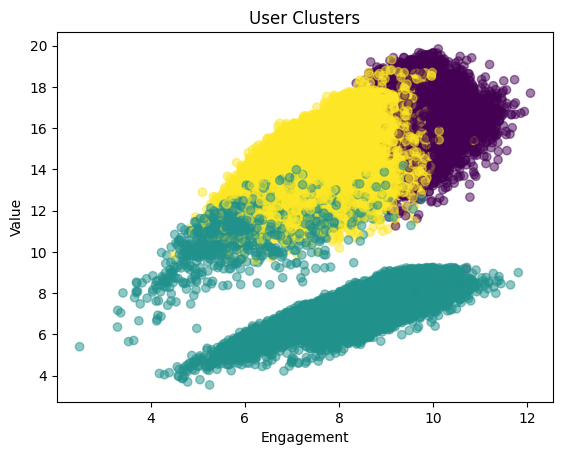

In [ ]:
plt.figure()

plt.scatter(
    df_cluster['engagement_index'],
    df_cluster['value_index'],
    c=df_cluster['cluster'],
    alpha=0.5
)

plt.xlabel("Engagement")
plt.ylabel("Value")
plt.title("User Clusters")

plt.show()

In [ ]:
# I dont think the clusters are antuarlly distributed

In [ ]:
df_cluster.groupby('cluster').mean().T

cluster,0,1,2
total_sessions,5.584357,5.524376,5.577138
conversion_rate,0.526075,0.218749,0.290470
avg_page_clicks,20.287320,15.662126,15.667824
total_page_clicks,113.086773,86.493064,87.287845
avg_session_duration_minutes,3.095405,3.173401,2.573995
total_trips,2.954192,1.278240,1.652053
completed_trips,2.912564,1.187409,1.601202
trips_per_session,0.533400,0.235122,0.299500
total_revenue,3538.604191,1756.140482,1147.160076
avg_revenue_per_trip,1319.407030,1424.699678,746.568559


In [ ]:
df_cluster['cluster'].value_counts()

,count
cluster,
0,84462
2,58052
1,15138


## 10. Clustering without indices

In [ ]:
# I'm not fully happay with the rsult.I'm going to explore another algorithm but not using the indicces

### Preparing the features

In [ ]:
#drop features that i don't need anymore like the indices and derivated features from them
features = df_prep.drop(columns=[
    'value_index',
    'engagement_index',
    'consistency_index',
    'all_inclusive',
    'recency'
]).copy()

# convert all featuresto numeric
features = features.apply(pd.to_numeric, errors='coerce')

In [ ]:
# scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)

### KMeans using all features

In [ ]:
# KMeansfrom sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42)
kmeans_labels = kmeans.fit_predict(X_scaled)

In [ ]:
kmeans_score = silhouette_score(X_scaled, kmeans_labels)
print("KMeans silhouette:", kmeans_score)

KMeans silhouette: 0.14923488577974872


### DBSCAn using all features

In [ ]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=0.5, min_samples=10)
dbscan_labels = dbscan.fit_predict(X_scaled)

In [ ]:
if len(set(dbscan_labels)) > 1:
    dbscan_score = silhouette_score(X_scaled, dbscan_labels)
    print("DBSCAN silhouette:", dbscan_score)
else:
    print("DBSCAN did not form valid clusters")

DBSCAN did not form valid clusters


In [ ]:
# DBSCAN and KMeans gave a bad result when using all the raw features

### PCA + Kmeans

In [ ]:
from sklearn.decomposition import PCA
# Icreate the PCA standard with 2 n_components. I'll run later a cumulative variance to decide the n_components
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

In [ ]:
from sklearn.metrics import silhouette_score

kmeans_pca = KMeans(n_clusters=3, random_state=42)
labels_pca = kmeans_pca.fit_predict(X_pca)

score_pca = silhouette_score(X_pca, labels_pca)
print("KMeans PCA silhouette:", score_pca)

KMeans PCA silhouette: 0.4458226549477711


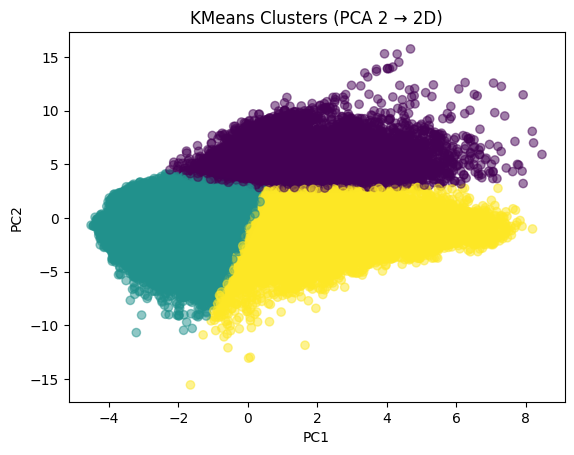

In [ ]:
pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(X_scaled)

plt.figure()

plt.scatter(
    X_pca_2d[:,0],
    X_pca_2d[:,1],
    c=labels_pca,
    alpha=0.5
)

plt.title("KMeans Clusters (PCA 2 → 2D)")
plt.xlabel("PC1")
plt.ylabel("PC2")

plt.show()

In [ ]:
# I'm pretty happy with this result. The clusters are more naturally separated. Even though the silhouette score wasn't the best.
# I'll run the DBSCAN algorithm to see which leads to better results.

### DBSCAN+ PCA

In [ ]:
dbscan_pca = DBSCAN(eps=0.5, min_samples=10)
labels_dbscan_pca = dbscan_pca.fit_predict(X_pca)

if len(set(labels_dbscan_pca)) > 1:
    score_dbscan_pca = silhouette_score(X_pca, labels_dbscan_pca)
    print("DBSCAN PCA silhouette:", score_dbscan_pca)

DBSCAN PCA silhouette: 0.6838384780759201


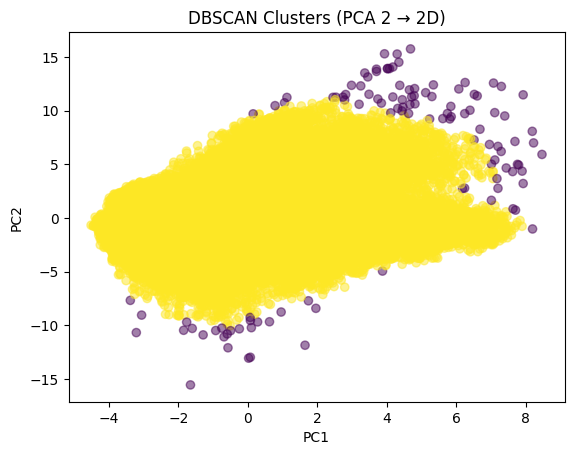

In [ ]:
# DBSCAN has a good silhouette score, let's see how do the clusters look on a scaterplot
pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(X_scaled)

plt.figure()

plt.scatter(
    X_pca_2d[:,0],
    X_pca_2d[:,1],
    c=labels_dbscan_pca,
    alpha=0.5
)

plt.title("DBSCAN Clusters (PCA 2 → 2D)")
plt.xlabel("PC1")
plt.ylabel("PC2")

plt.show()

In [ ]:
# DBSCAN found two clusters with relatively good silhouette scores, but the clusters in the scatter plot don't look good at all.
# I'm starting to think that DBSCAN isn't suitable for this dataset.

###PCA 14 components

In [ ]:
# Now I want to find out the ideal vlaue of the n_components

In [ ]:
pca_full = PCA()
pca_full.fit(X_scaled)

explained_variance = pca_full.explained_variance_ratio_

cumulative_variance = np.cumsum(explained_variance)

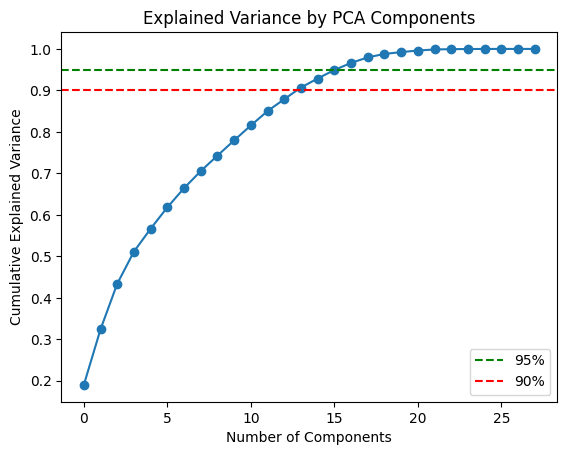

In [ ]:
plt.figure()

plt.plot(cumulative_variance, marker='o')

plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Explained Variance by PCA Components")

plt.axhline(y=0.95, color='g', linestyle='--', label='95%')
plt.axhline(y=0.90, color='r', linestyle='--', label='90%')

plt.legend()

plt.show()

In [ ]:
# with 14 n_compnentes is explained 90% of the variance of the data set. With 16 n_compnents is 95%
#I think

In [ ]:
# new PCA with 14 components
from sklearn.decomposition import PCA

pca_14 = PCA(n_components=14)
X_pca_14 = pca_14.fit_transform(X_scaled)


### KMeans+ PCA n=14

In [ ]:
from sklearn.cluster import KMeans

kmeans_pca_14 = KMeans(n_clusters=3, random_state=42)
labels_kmeans_pca_14 = kmeans_pca_14.fit_predict(X_pca_14)

In [ ]:
from sklearn.metrics import silhouette_score

score_kmeans_pca_14 = silhouette_score(X_pca_14, labels_kmeans_pca_14)
print("KMeans PCA (14) silhouette:", score_kmeans_pca_14)

KMeans PCA (14) silhouette: 0.15320413008787842


In [ ]:
# KMEans had a bad silhouete score

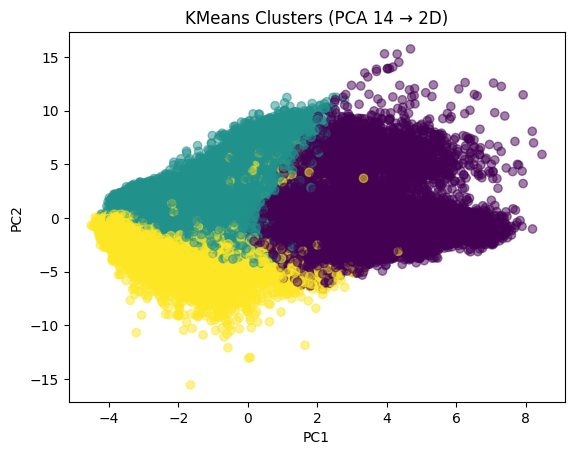

In [ ]:
import matplotlib.pyplot as plt

pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(X_scaled)

plt.figure()

plt.scatter(
    X_pca_2d[:,0],
    X_pca_2d[:,1],
    c=labels_kmeans_pca_14,
    alpha=0.5
)

plt.title("KMeans Clusters (PCA 14 → 2D)")
plt.xlabel("PC1")
plt.ylabel("PC2")

plt.show()

In [ ]:
# The clusters are not clearly separated. I think setting n_components to 2 produced a better result.

### DBSCAN + PCA n=14

In [ ]:
# now I use the pca_14 to train a DBSCAN algorithm.
from sklearn.cluster import DBSCAN

dbscan_pca_14 = DBSCAN(eps=0.5, min_samples=10)
labels_dbscan_pca_14 = dbscan_pca_14.fit_predict(X_pca_14)

In [ ]:
if len(set(labels_dbscan_pca_14)) > 1:
    score_dbscan_pca_14 = silhouette_score(X_pca_14, labels_dbscan_pca_14)
    print("DBSCAN PCA (14) silhouette:", score_dbscan_pca_14)
else:
    print("DBSCAN did not form valid clusters")

DBSCAN did not form valid clusters


In [ ]:
# DBSCAN couldn't find any clusters

## 11. Clusters Definition

“While higher-dimensional representations preserved more variance, they introduced noise that reduced cluster separability. A lower-dimensional PCA projection (2 components) revealed a clearer structure in the data, allowing KMeans to identify well-defined and balanced user segments.

This highlights that dimensionality reduction is not only a technical step but also a tool to uncover the most meaningful structure in user behavior.”

In [ ]:
pca_final = PCA(n_components=2)
X_final = pca_final.fit_transform(X_scaled)

kmeans_final = KMeans(n_clusters=3, random_state=42)
df_prep['cluster_final'] = kmeans_final.fit_predict(X_final)

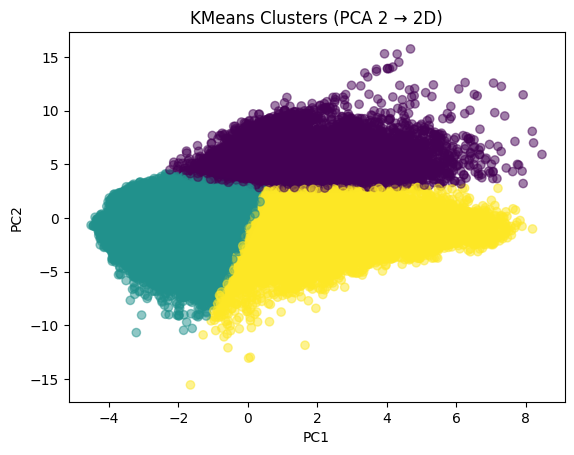

In [ ]:
pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(X_scaled)

plt.figure()

plt.scatter(
    X_pca_2d[:,0],
    X_pca_2d[:,1],
    c=df_prep['cluster_final'],
    alpha=0.5
)

plt.title("KMeans Clusters (PCA 2 → 2D)")
plt.xlabel("PC1")
plt.ylabel("PC2")

plt.show()

## 12. EDA on the clusters / segments

In [ ]:
df_prep.groupby('cluster_final').mean().T

cluster_final,0,1,2
total_sessions,5.759792,5.543238,5.597925
conversion_rate,0.293369,0.280287,0.581124
avg_page_clicks,48.141577,14.853670,19.205098
total_page_clicks,274.086647,82.093160,107.128141
avg_session_duration_minutes,20.446387,1.874890,2.439486
total_trips,2.668694,1.543394,3.228286
completed_trips,1.682493,1.536313,3.219319
trips_per_session,0.468154,0.281556,0.582707
total_revenue,1699.467390,1418.555186,3882.607273
avg_revenue_per_trip,614.676825,978.197630,1341.933177


In [ ]:
df_prep['cluster_final'].value_counts(normalize=True)

,proportion
cluster_final,
1,0.528569
2,0.428678
0,0.042752


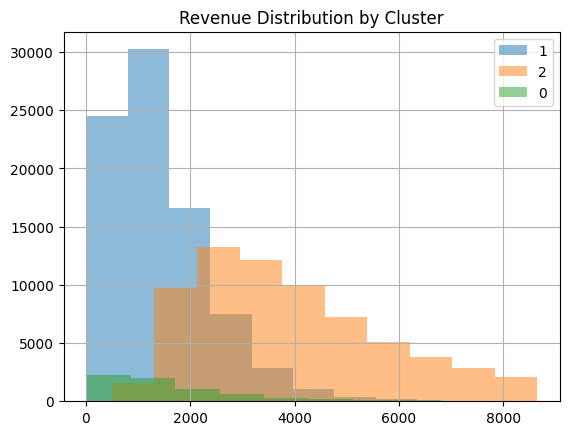

In [ ]:
for c in df_prep['cluster_final'].unique():
    df_prep[df_prep['cluster_final'] == c]['total_revenue'].hist(alpha=0.5)

plt.legend(df_prep['cluster_final'].unique())
plt.title("Revenue Distribution by Cluster")
plt.show()

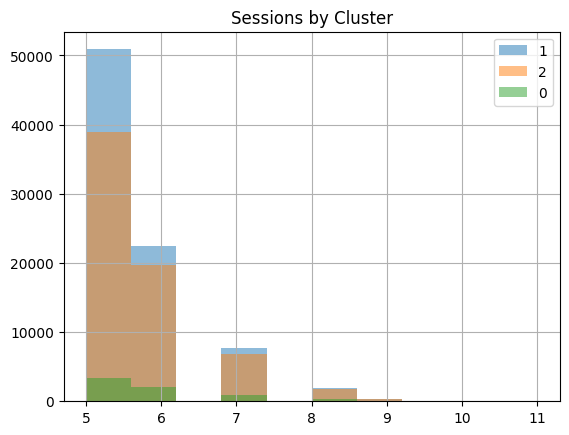

In [ ]:
for c in df_prep['cluster_final'].unique():
    df_prep[df_prep['cluster_final'] == c]['total_sessions'].hist(alpha=0.5)

plt.legend(df_prep['cluster_final'].unique())
plt.title("Sessions by Cluster")
plt.show()

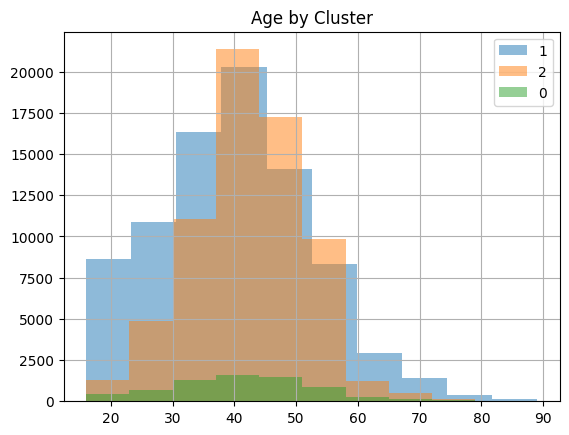

In [ ]:
for c in df_prep['cluster_final'].unique():
    df_prep[df_prep['cluster_final'] == c]['age'].hist(alpha=0.5)

plt.legend(df_prep['cluster_final'].unique())
plt.title("Age by Cluster")
plt.show()

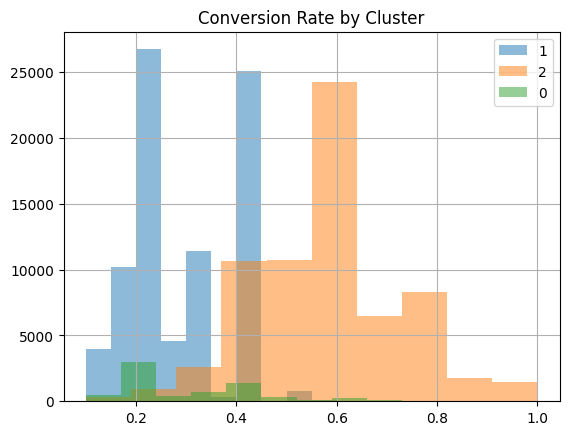

In [ ]:
for c in df_prep['cluster_final'].unique():
    df_prep[df_prep['cluster_final'] == c]['conversion_rate'].hist(alpha=0.5)

plt.legend(df_prep['cluster_final'].unique())
plt.title("Conversion Rate by Cluster")
plt.show()

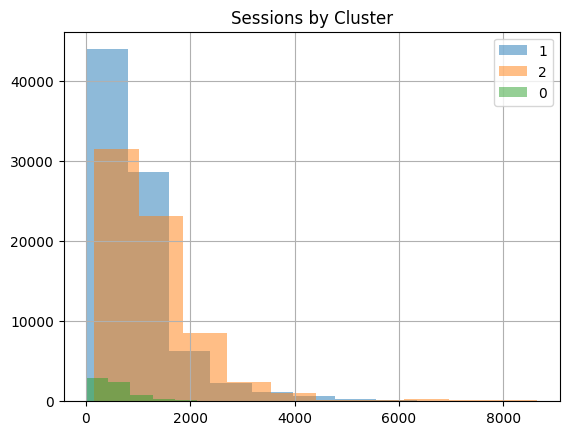

In [ ]:
for c in df_prep['cluster_final'].unique():
    df_prep[df_prep['cluster_final'] == c]['avg_revenue_per_trip'].hist(alpha=0.5)

plt.legend(df_prep['cluster_final'].unique())
plt.title("Sessions by Cluster")
plt.show()

In [ ]:
df_prep.groupby('cluster_final')[[
    'conversion_rate',
    'cancel_rate',
    'avg_revenue_per_trip',
    'avg_distance_km'
]].mean()

,conversion_rate,cancel_rate,avg_revenue_per_trip,avg_distance_km
cluster_final,,,,
0,0.293369,0.396003,614.676825,1835.123887
1,0.280287,0.003330,978.197630,1770.045650
2,0.581124,0.002880,1341.933177,2200.877497


In [ ]:
df_prep.groupby('cluster_final')[[
    'flight_ratio',
    'hotel_ratio',
    'rooms',
    'nights'
]].mean()

,flight_ratio,hotel_ratio,rooms,nights
cluster_final,,,,
0,0.885355,0.785160,1.138930,4.237666
1,0.790643,0.890667,1.059809,3.697553
2,0.860441,0.901982,1.218458,3.999088


In [ ]:
df_prep.groupby('cluster_final')[[
    'age',
    'has_children',
    'married'
]].mean()

,age,has_children,married
cluster_final,,,
0,40.724184,0.314837,0.407567
1,39.986331,0.337982,0.409960
2,41.912802,0.285964,0.389438


In [ ]:
# Lets see a parallel plot
features_plot = [
    'total_sessions',
    'conversion_rate',
    'total_revenue',
    'avg_revenue_per_trip',
    'cancel_rate',
    'avg_distance_km',
    'nights',
    'rooms',
    'avg_trip_duration',
    'flight_ratio',
    'hotel_ratio',
    'checked_bags',
    'seats',
    'married',
    'has_children',
    'age'
]

In [ ]:
df_parallel = df_prep.groupby('cluster_final')[features_plot].mean().reset_index()

In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

df_scaled = df_parallel.copy()
df_scaled[features_plot] = scaler.fit_transform(df_parallel[features_plot])

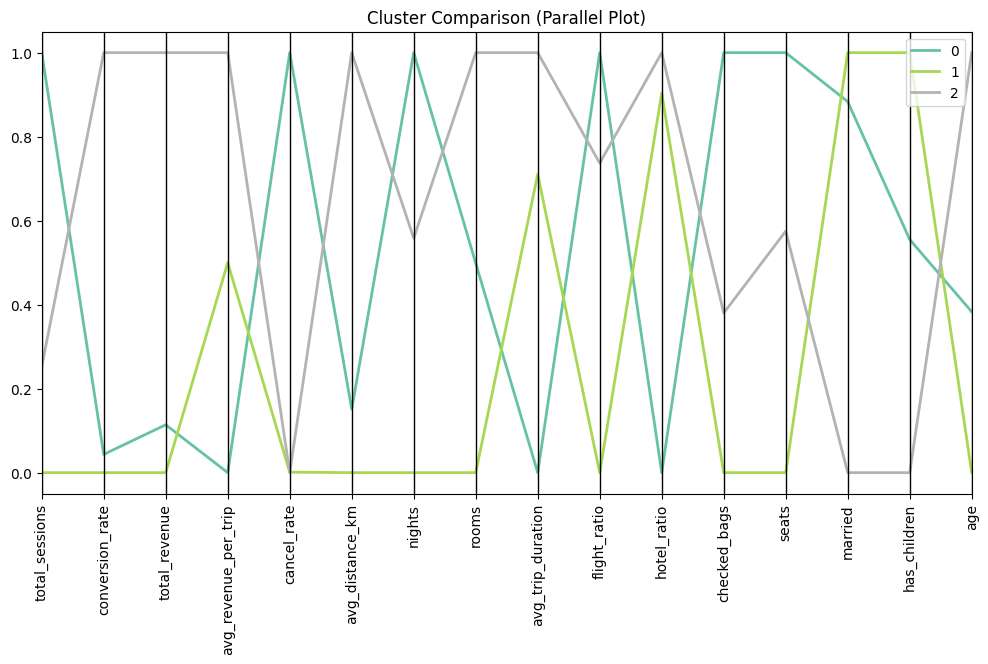

In [ ]:
from pandas.plotting import parallel_coordinates
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

parallel_coordinates(
    df_scaled,
    class_column='cluster_final',
    colormap=plt.cm.Set2,
    linewidth=2
)

plt.grid(False)
plt.title("Cluster Comparison (Parallel Plot)")
plt.xticks(rotation=90)

plt.show()

In [ ]:
df_prep.groupby('cluster_final')[[
    'total_sessions',
    'conversion_rate',
    'total_revenue',
    'cancel_rate'
]].mean()

,total_sessions,conversion_rate,total_revenue,cancel_rate
cluster_final,,,,
0,5.759792,0.293369,1699.467390,0.396003
1,5.543238,0.280287,1418.555186,0.003330
2,5.597925,0.581124,3882.607273,0.002880


In [ ]:
df_prep.groupby('cluster_final').mean().T

cluster_final,0,1,2
total_sessions,5.759792,5.543238,5.597925
conversion_rate,0.293369,0.280287,0.581124
avg_page_clicks,48.141577,14.853670,19.205098
total_page_clicks,274.086647,82.093160,107.128141
avg_session_duration_minutes,20.446387,1.874890,2.439486
total_trips,2.668694,1.543394,3.228286
completed_trips,1.682493,1.536313,3.219319
trips_per_session,0.468154,0.281556,0.582707
total_revenue,1699.467390,1418.555186,3882.607273
avg_revenue_per_trip,614.676825,978.197630,1341.933177


In [ ]:
df_prep[df_prep['cluster_final'] == 0][[
    'nights',
    'avg_trip_duration'
]].describe()

,nights,avg_trip_duration
count,6740.000000,6740.000000
mean,4.237666,4.528384
std,3.065500,2.780867
min,0.000000,0.000000
25%,2.000000,3.000000
50%,3.500000,4.000000
75%,6.000000,5.500000
max,27.000000,29.000000


In [ ]:
# there are some incosistencies on the parallel plot. Like nights=high trip_duration=low

## 13. another look on Kmeans PCA n=14

In [ ]:
df_prep = df_prep.copy()
df_prep['cluster_pca14'] = labels_kmeans_pca_14

In [ ]:
# Lets see a parallel plot
features_plot = [
    'total_sessions',
    'conversion_rate',
    #'total_revenue', # total_revenue dominates the chart and compress the rest of the features
    #'avg_revenue_per_trip',
    'cancel_rate',
    #'avg_distance_km', # this one also, I'll goin to analyze them separately
    'nights',
    'rooms',
    'avg_trip_duration',
    'flight_ratio',
    'hotel_ratio',
    'checked_bags',
    'seats',
    'married',
    'has_children',
    'age'
]

In [ ]:
df_parallel = df_prep.groupby('cluster_pca14')[features_plot].mean().reset_index()

In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

df_scaled = df_parallel.copy()
df_scaled[features_plot] = scaler.fit_transform(df_parallel[features_plot])

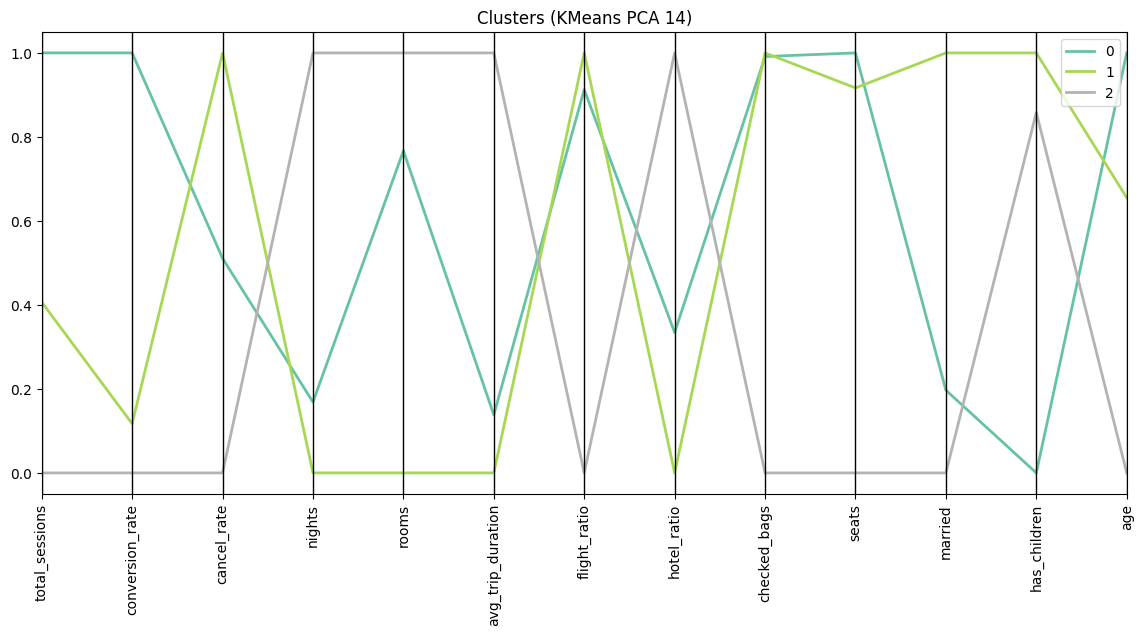

In [ ]:
from pandas.plotting import parallel_coordinates
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))

parallel_coordinates(
    df_scaled,
    class_column='cluster_pca14',
    colormap=plt.cm.Set2,
    linewidth=2
)

plt.grid(False)

plt.title("Clusters (KMeans PCA 14)")
plt.xticks(rotation=90)

plt.show()

In [ ]:
df_prep.groupby('cluster_pca14')[['total_revenue']].describe()

total_revenue                                              \
                      count         mean          std    min        25%   
cluster_pca14                                                             
0                   64806.0  3781.049845  1791.482023  78.84  2372.6750   
1                   74040.0  1368.100342   918.589607   4.38   697.8625   
2                   18806.0  2431.570403  1850.568658  32.00   960.0000   

                                             
                    50%        75%      max  
cluster_pca14                                
0              3435.115  4900.2950  8651.08  
1              1173.190  1812.4500  8601.16  
2              1970.000  3454.9425  8651.18

In [ ]:
df_prep.groupby('cluster_pca14')[['avg_distance_km']].describe()

avg_distance_km                                                 \
                        count         mean          std  min     25%     50%   
cluster_pca14                                                                  
0                     64806.0  2173.097506  1138.223104  0.0  1520.0  2031.0   
1                     74040.0  2102.722245  1424.172006  0.0  1184.0  1971.0   
2                     18806.0   642.934702  1430.484015  0.0     0.0     0.0   

                                
                  75%      max  
cluster_pca14                   
0              2634.0  16534.0  
1              2776.0  16858.0  
2               639.5  16453.0

<Axes: >

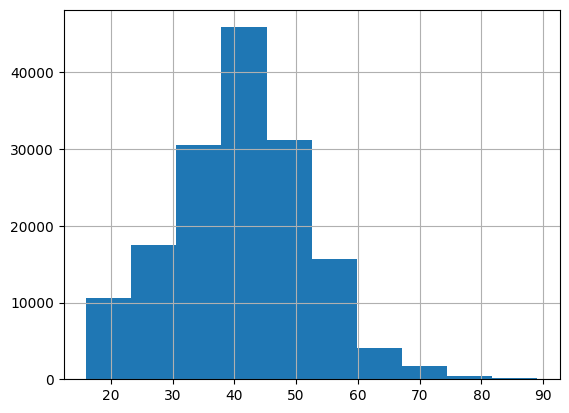

In [ ]:
df_prep['age'].hist()

The segmentation reveals three distinct user archetypes: premium frequent travelers, high-friction family travelers, and low-activity leisure users. Each segment requires a fundamentally different strategy, ranging from experience optimization to friction reduction and re-engagement.

## 14. Segments final definition

After the clustering and EDa process I came out with the following segments:

1. No-Purchase Users
Users with multiple sessions but no bookings or revenue, indicating browsing behavior without conversion.

2. High-Value Users
Top revenue contributors with strong purchasing power and efficient booking behavior.

3. Trips Without Revenue
Users who completed bookings but generated no revenue, likely due to cancellations or edge-case transactions.

4. Premium Long-Haul Travelers (Cluster 0)
Highly active users with high revenue, long-distance trips, and frequent bookings, typically traveling without family.

5. High-Friction Family Travelers (Cluster 1)
Users with family-related travel patterns, high cancellation rates, and lower revenue, indicating booking complexity and friction.

6. Low-Activity Leisure Travelers (Cluster 2)
Occasional travelers with lower engagement, stable behavior, and longer stays, often traveling shorter distances with family.

## 15. Finalzing + Data Export

In [ ]:
df_final = df.copy() # copy of the original df

In [ ]:
df_final['segment_label'] = None # create label's column

In [ ]:
df_final.loc[df_final['user_id'].isin(df_high_value['user_id']), 'segment_label'] = 'High Value' # assign high_value label

In [ ]:
df_final.loc[df_final['user_id'].isin(df_trips_no_revenue['user_id']), 'segment_label'] = 'Trips No Revenue' # no revenue label

In [ ]:
df_final.loc[df_final['user_id'].isin(df_no_purchase['user_id']), 'segment_label'] = 'No Purchase' # no bookings label

In [ ]:
# Icheck first that df_prep and df_model still have the same index in order to add the user_id column
display(df_model.head(10))
display(df_prep.head(10))

,user_id,total_sessions,conversion_rate,avg_page_clicks,total_page_clicks,avg_session_duration_minutes,last_session,total_trips,completed_trips,trips_per_session,...,discount_ratio,flight_ratio,hotel_ratio,avg_distance_km,account_age_days,age,has_children,married,has_trips,has_revenue
0,134,5,0.40,18.40,92,2.28,2023-07-19 17:03:39.000,2,2,0.40,...,0.00,0.50,1.0,1652.0,877,35,True,False,True,True
1,453,5,0.60,15.40,77,1.92,2023-05-17 12:42:14.000,3,3,0.60,...,0.33,1.00,1.0,1492.0,865,28,False,False,True,True
2,519,5,0.20,8.20,41,1.02,2023-06-11 18:13:15.000,1,1,0.20,...,0.00,1.00,1.0,2166.0,864,45,False,False,True,True
5,949,5,0.40,26.40,132,3.25,2023-04-02 17:47:29.000,2,2,0.40,...,0.50,1.00,0.5,3708.0,848,53,False,True,True,True
6,999,5,0.40,31.00,155,3.85,2023-07-02 20:41:07.000,2,2,0.40,...,0.00,1.00,1.0,1158.0,848,16,False,False,True,True
8,1220,5,0.20,12.60,63,1.56,2023-05-15 21:33:53.000,1,1,0.20,...,0.00,0.00,1.0,NaN,842,39,True,False,True,True
9,1406,5,0.60,17.20,86,2.13,2023-04-18 17:10:19.000,3,3,0.60,...,0.00,0.33,1.0,176.0,838,36,False,False,True,True
10,1414,6,0.17,21.67,130,2.69,2023-07-10 01:49:36.000,1,1,0.17,...,1.00,1.00,1.0,4289.0,838,33,False,False,True,True
11,1489,5,0.40,9.40,47,1.16,2023-06-24 22:33:16.000,2,2,0.40,...,0.00,1.00,0.5,2044.0,837,38,False,False,True,True
12,1557,5,0.20,8.80,44,1.10,2023-06-26 20:42:46.000,1,1,0.20,...,1.00,1.00,1.0,2326.0,837,51,True,False,True,True


,total_sessions,conversion_rate,avg_page_clicks,total_page_clicks,avg_session_duration_minutes,total_trips,completed_trips,trips_per_session,total_revenue,avg_revenue_per_trip,...,has_children,married,days_since_last_session,all_inclusive,value_index,recency,engagement_index,consistency_index,cluster_final,cluster_pca14
0,5,0.40,18.40,92,2.28,2,2,0.40,1094.49,547.25,...,True,False,11,0.50,14.617078,0.083333,8.441779,9.376259,1,1
1,5,0.60,15.40,77,1.92,3,3,0.60,3110.63,1036.88,...,False,False,74,1.00,15.853478,0.013333,9.245370,10.150179,2,0
2,5,0.20,8.20,41,1.02,1,1,0.20,570.77,570.77,...,False,False,49,1.00,15.229836,0.020000,6.985439,9.455877,1,1
5,5,0.40,26.40,132,3.25,2,2,0.40,1385.95,692.98,...,False,True,119,0.50,15.660961,0.008333,8.947181,9.342671,1,1
6,5,0.40,31.00,155,3.85,2,2,0.40,1897.57,948.79,...,False,False,28,1.00,15.311554,0.034483,9.441731,9.842671,1,1
8,5,0.20,12.60,63,1.56,1,1,0.20,3760.00,3760.00,...,True,False,76,0.00,8.432440,0.012987,9.247122,8.430114,1,2
9,5,0.60,17.20,86,2.13,3,3,0.60,5214.19,1738.06,...,False,False,103,0.33,13.567250,0.009615,9.861698,9.448505,2,0
10,6,0.17,21.67,130,2.69,1,1,0.17,711.33,711.33,...,False,False,20,1.00,16.102583,0.047619,7.952480,9.425358,1,1
11,5,0.40,9.40,47,1.16,2,2,0.40,2230.31,1115.16,...,False,False,36,0.50,15.540803,0.027027,8.471526,9.329630,1,1
12,5,0.20,8.80,44,1.10,1,1,0.20,1720.54,1720.54,...,True,False,34,1.00,16.403310,0.028571,8.154817,9.424165,1,1


In [ ]:
# I add the user_id colums to the df_prep and create a new df in order to assign the cluster labels later
df_prep_model = df_model[['user_id']].copy()

df_prep_model['cluster_pca14'] = labels_kmeans_pca_14

In [ ]:
len(df_prep_model) == len(labels_kmeans_pca_14)

True

In [ ]:
#in order to assign the clusters a label I map them first
#Here Icreate the segment's names
cluster_map = {
    0: 'Premium Long-Haul',
    1: 'High Friction Family',
    2: 'Low Activity Leisure'
}

In [ ]:
#Imap the name to the cluster labels(0,1,2)
df_prep_model['cluster_label'] = df_prep_model['cluster_pca14'].map(cluster_map)

In [ ]:
df_final = df_final.merge(
    df_prep_model[['user_id', 'cluster_label']],
    on='user_id',
    how='left'
)

In [ ]:
df_final['segment_label'] = df_final['segment_label'].fillna(df_final['cluster_label'])

In [ ]:
df_final = df_final.drop(columns=['cluster_label'])

In [ ]:
# qiuck check
df_final.head()

,user_id,total_sessions,conversion_rate,avg_page_clicks,total_page_clicks,avg_session_duration_minutes,last_session,total_trips,completed_trips,trips_per_session,...,flight_ratio,hotel_ratio,avg_distance_km,account_age_days,age,has_children,married,has_trips,has_revenue,segment_label
0,134,5,0.4,18.4,92,2.28,2023-07-19 17:03:39.000,2,2,0.4,...,0.5,1.0,1652.0,877,35,True,False,True,True,High Friction Family
1,453,5,0.6,15.4,77,1.92,2023-05-17 12:42:14.000,3,3,0.6,...,1.0,1.0,1492.0,865,28,False,False,True,True,Premium Long-Haul
2,519,5,0.2,8.2,41,1.02,2023-06-11 18:13:15.000,1,1,0.2,...,1.0,1.0,2166.0,864,45,False,False,True,True,High Friction Family
3,577,5,NaN,11.4,57,1.41,2023-06-05 17:03:28.000,0,0,0.0,...,NaN,NaN,NaN,863,41,False,False,False,False,No Purchase
4,638,5,NaN,10.0,50,1.25,2023-03-20 11:30:16.000,0,0,0.0,...,NaN,NaN,NaN,858,21,False,False,False,False,No Purchase


In [ ]:
df_final['segment_label'].value_counts()

,count
segment_label,
High Friction Family,74040
Premium Long-Haul,64806
No Purchase,20119
Low Activity Leisure,18806
High Value,8297
Trips No Revenue,3364


In [ ]:
len(df) == len(df_final)

True

In [ ]:
df_final['segment_label'].isna().sum()

np.int64(0)

In [ ]:
df_segments = df_final[['user_id', 'segment_label']].copy()

In [ ]:
#Export user_segments table
df_segments.to_csv("user_segments.csv", index=False)

In [ ]:
df_final.to_csv("user_features_labels.csv", index=False)

In [ ]:
df_segments['segment_label'].value_counts()

,count
segment_label,
High Friction Family,74040
Premium Long-Haul,64806
No Purchase,20119
Low Activity Leisure,18806
High Value,8297
Trips No Revenue,3364


In [ ]:
#final export of the segments
for segment in df_final['segment_label'].unique():

    df_segment = df_final[df_final['segment_label'] == segment]

    filename = segment.lower().replace(" ", "_") + ".csv"

    df_segment.to_csv(filename, index=False)